In [3]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np
import tensorflow as tf
import sys

In [2]:
import sys
fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)
    
general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

In [4]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


In [5]:
def remove_labels(new_test_datasets):
    new_no_label_test_datasets = []
    for dataset in new_test_datasets:
        if 'IsBlast' in dataset.columns:
            dataset = dataset.drop(columns = ['IsBlast'])
        
        new_no_label_test_datasets.append(dataset)
    print(len(new_no_label_test_datasets))
    return new_no_label_test_datasets

def show_blast_distribution(ALL_DATASETS, return_perc = False):
    tot_perc_list = []
    for i, dataset in enumerate(ALL_DATASETS):
        blast_n = (dataset['IsBlast'] == 1).sum()
        tot_perc_list.append(round((blast_n/len(dataset))*100, 2))
    
    positions = range(1, len(tot_perc_list) + 1)
    
    fig, ax1 = plt.subplots(figsize = [len(positions)/2,4])
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), [max(tot_perc_list)]*len(tot_perc_list), alpha = 0.5)
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), tot_perc_list)
    ax1.set_xticks(positions)
    
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    ax2.set_xticklabels(tot_perc_list, size = 'x-small')
    plt.show()

    if return_perc:
        return tot_perc_list

def grid_or_rand_model(grid):
    if grid:
        remove_from_cache(['old_cellCnn.model_grid'])
        from old_cellCnn.model_grid import CellCnn
    else:
        remove_from_cache(['old_cellCnn.model'])
        from old_cellCnn.model import CellCnn
    return CellCnn

def train_val_finalizing(train_datasets, val_datasets, grid, labels):
    
    if grid:
        train = remove_labels(train_datasets)
        val = remove_labels(val_datasets)
        print(f'_abels from Train and Validations Sets have been REMOVED.\nGrid Search Ready!')
    else:
        if not labels: # if random search but we don't want use labels
            train = remove_labels(train_datasets)
            val = remove_labels(val_datasets)
            print(f'labels from Train and Validations Sets have been REMOVED.\nRandom Search Ready!')
            
        else:
            train = train_datasets
            val = val_datasets
            print(f'Labels from Train and Validations Sets have been PRESERVED.\nRandom Search Ready!')
            
    return train, val

def prepare_results_to_save(results_list, par_list = ['config', 'model_sorted_idx']):
    tot_trials_res = []

    for res in results_list:
        needed_results = {}
        for key, value in res.items():
            if key in par_list:
                needed_results[key] = value
                
        tot_trials_res.append(needed_results)
    return tot_trials_res

def retrieve_labels(datasets_extracted, remove = False, concat = False):
    
    per_donor_original_datasets = []
    per_donor_original_y = []

    for donor in datasets_extracted:
        donor_datasets = []
        donor_ys = []
        for dataset in donor:
            if (dataset['IsBlast'] == 1).sum() > 0:
                donor_ys.append(1)
            else:
                donor_ys.append(0)
                
            if remove:
                dataset = dataset.drop(columns = ['IsBlast'])

            donor_datasets.append(dataset)

        if concat:
            per_donor_original_datasets += donor_datasets
            per_donor_original_y += donor_ys
        else:
            per_donor_original_datasets.append(donor_datasets)
            per_donor_original_y.append(donor_ys)
            
    return per_donor_original_datasets, per_donor_original_y 

def subset_sampling(dataset, ncells, nsubsets, seed):
    resampled_datasets = []
    resampled_y = []
    blast_perc = []
    
    for i in range(nsubsets):
        seed += 10
        #print(f'seed:{seed}')
        resampled_cells = dataset.sample(ncells, replace = True, random_state = seed).reset_index(drop=True) # sample cells
            
        if (resampled_cells['IsBlast'] == 1).sum() > 0: #check label
                resampled_y.append(1)
                blast_perc.append((resampled_cells[resampled_cells['IsBlast'] == 1]).sum()/len(resampled_cells))
        else:
                resampled_y .append(0)
                blast_perc.append(0)
        resampled_cells = resampled_cells.drop(columns = ['IsBlast']) #remove isblast column

        resampled_datasets.append(resampled_cells) 
    return    resampled_datasets,  resampled_y , blast_perc, seed


def get_timepoints_predictions(total_pred_lists, per_donor_original_test_y, threshold):
    total_labels = []
    
    for patient in total_pred_lists:
        patient_timepoints_labels = []
        
        for timepoint in patient:
            timepoint_f1_scores = []
            blast_labelled_timepoint_scores = []
            
            true_y = timepoint.iloc[-1]
            
            for trial in range(len(timepoint.iloc[:-1])): # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                sub = timepoint.iloc[trial]               # each sub is a pediction of the 20 samples of a single timepoint
                blast_labelled_perc = sub.sum()/len(true_y)
                blast_labelled_timepoint_scores.append(blast_labelled_perc) #percentage of timepoints labelled as with blast cells
     
            mean_timepoint_blast_score = np.mean(blast_labelled_timepoint_scores) # mean percentage of timepoints labelled as with blast cells
            
            if mean_timepoint_blast_score >= threshold*0.01:
                patient_timepoints_labels.append(1)
            else:
                patient_timepoints_labels.append(0)
                
        total_labels.append(patient_timepoints_labels)
    return total_labels


def get_trial_pred_per_timepoint(total_pred_lists, per_donor_original_test_y):
    plot_data = []
    boxplot_data = []
    total_timepoint_prediction_per_trial = []
    
    for patient, patient_ys in zip(total_pred_lists, per_donor_original_test_y):
        timepoint_prediction_per_trial = []
        
        for timepoint, true_timepoint_y in zip(patient, patient_ys):
            label_str = "Positive" if true_timepoint_y == 1 else "Negative"
            
            trial_level_label_prediction = []
            true_y = timepoint.iloc[-1]
            timepoint_boxplot_data = []
            
            for trial in range(len(timepoint.iloc[:-1])): # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                sub = timepoint.iloc[trial]               # each sub is a pediction of the 20 samples of a single timepoint
                
                trial_perc = sub.sum()/len(true_y)
                #trial_perc = sub.sum()/min(1, true_y.sum())
            
                #trial_level_label_prediction.append((blast_labelled_perc >= threshold*0.01).astype(int))
                plot_data.append({
                "True_Label": label_str,
                "Timepoint_Score": trial_perc
                })
                
                timepoint_boxplot_data.append(trial_perc)
                
            boxplot_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_boxplot_data
                })
                
    return plot_data, boxplot_data

def compute_timepoint_best_f1(timepoint_preds):
        """we are taking the best f1 score. because we are not tuning the model. we are just trying to predict the label of the timepoint"""
        timepoint_score = []
        
        resampled_true_y = timepoint_preds.iloc[-1] # get labels of resampled subsets
        #print(timepoint_preds.iloc[:-1]) #labels

        # initialize variables
        best_f1 = -1
        counter = 0
        
        for h in range(len(timepoint_preds) - 1):
            sub = timepoint_preds.iloc[h] # extrsct trial pediction
            
            f1 = f1_score(resampled_true_y, sub, pos_label = 1) # compute the f1_score
            if f1 > best_f1:
                best_f1_idx = counter
            counter += 1
            
        print(best_f1_idx)   
        best_sub = timepoint_preds.iloc[best_f1_idx]
        #print(len(true_y))
        blast_score = best_sub.sum() 
        print('')
        #print(best_sub)
        #print(f'blast_score: {blast_score}\n')
        timepoint_score = blast_score.sum()/len(resampled_true_y)
        return (timepoint_score, list(resampled_true_y))


def find_threshold(total_scores, per_donor_original_val_y):
    best_f1 = -1
    best_thr = -1
    tot_mean_f1_scores = []
    threshold_predictions = []
    for threshold in list(range(1,101)):
        f1_scores = []
        patient_predictions = []
        for patient_score, patient_y in zip(total_scores, per_donor_original_val_y):
            scores = []
            
            for timep in patient_score:
                # get mean columns predicted probabilities 
                scores.append(timep[0]) 
            
            y_pred = []
            y_pred = (np.array(scores) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
            #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')
            #print(patient_y)
            #print(y_pred)
            timepoint_f1_score = f1_score(patient_y, y_pred, pos_label = 1, zero_division=1)
            #print(f'f1_score: {timepoint_f1_score}\n')
        
            f1_scores.append(timepoint_f1_score)
            
            patient_predictions.append(list(y_pred))
            
        threshold_predictions.append(patient_predictions)
    
        #print(f1_scores)
        mean_f1_score = np.mean(f1_scores)
        tot_mean_f1_scores.append(mean_f1_score)
        
        if mean_f1_score > best_f1:
                best_f1 = mean_f1_score
                best_thr = threshold*0.01
        #print('')
    
        #patient_f1_scores.append(timepoint_f1_score)
    #plot thresholds
    plt.plot(list(range(1,101)), tot_mean_f1_scores)
    #for th in threshold_predictions:
        #print(th)

    #find threshold
    max_mean_f1 = max(tot_mean_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_mean_f1_scores) if f1 == max_mean_f1]
    #print(best_thresholds_idx)
    
    robust_best_thr_idx = np.median(best_thresholds_idx)
    #print(np.median(list(range(5))))
    print(f'Chosen threshold: {robust_best_thr_idx}' )
    return robust_best_thr_idx


def flatten(nested):
    if nested is None:
        return []
    if not isinstance(nested, (list, tuple)):
        return [nested]
    nested = list(nested)
    result = []
    for item in nested:
        result.extend(flatten(item))
    return result



def CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()
    
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)
    
    #print(h_pat, b_pat, m_pat)
    
    train_perm = []
    for hp in h_pat:
        for mp in m_pat:
            train_perm.append([hp, mp, b_pat[0], b_pat[1]])
            train_perm.append([hp, mp, b_pat[0], b_pat[2]])
            train_perm.append([hp, mp, b_pat[1], b_pat[2]])
    
    tot_train_val_perm = h_pat + b_pat + m_pat
    val_perm = []
    for element in train_perm:
        q = set(tot_train_val_perm.copy()) - set(element)
        val_perm.append(list(q))
    
    for t_fold, v_fold in zip(train_perm, val_perm):
        print(t_fold, v_fold)
    return train_perm, val_perm


def chosen_folds(iterations, train_perm, val_perm, seed = 42):
    print(seed)
    np.random.seed(seed)
    tot_perm = len(train_perm)
    
    idx = np.arange(tot_perm)
    np.random.shuffle(idx)

    chosen_folds = []
    for index in idx[:iterations]:
        chosen_folds.append([train_perm[index], val_perm[index]])
    
    return chosen_folds


def run_training(CellCnn, new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, seed_list, hyper,
                             grid = True, labels = False, trials = 1, cells_per_sub = 200, best_nsub = 200):
    

    train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)
    new_test_datasets = flatten(new_test_datasets)
    test = remove_labels(new_test_datasets)
    no_label_val = remove_labels(new_val_datasets)

    models_lists = trials_train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                                  new_train_y, 
                                  val, #new_val_datasets_no_labels, 
                                  new_val_y, test, trials = trials,
                                  n_cell = cells_per_sub, nsubset = best_nsub,
                                  max_epochs=50, nrun=15, seed_list = seed_list, hyper = hyper)
    
    return models_lists

def val_res_pred(models_lists, per_donor_original_val_datasets, n, k, seed):
    per_donor_resampled_datasets =[]
    per_donor_resampled_y = []
    per_donor_perc = []
    
    mean_probs_per_patient = []
    total_pred_lists = []
    total_trial_pred_lists = []
    
    counter = 1
    for patient in per_donor_original_val_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
    
        timepoints_mean_probs = []
        patient_pred_list = []
        patient_trial_pred_list = []
        for file in patient:
            # for each dataset, multiple subsets of n cells are resampled
            resampled_datasets,  resampled_y , blast_perc, seed =  subset_sampling(file, ncells = n, nsubsets = k, seed = seed)
    
            print(f'Prediction {counter}')
            counter += 1
            new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
            positive_probs = []
            positive_probs_mean = []
            
            for trial in new_datasets_predictions_list:
                positive_probs.append(pd.DataFrame(trial)[1]) # appends the probability of positive classification
    
            all_trials_probs_array = np.array(positive_probs) #it converts the list of (list of) probabilities into an array of lists of probs
    
            # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
            positive_probs_mean = np.mean(all_trials_probs_array, axis=0)
    
            print(f'Len of Mean: {len(positive_probs_mean)}')
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(positive_probs) # stores all probabilities af all trials
    
            for trial in positive_probs_mean:
                print(trial)
            ## assigns mean probabilities to its true resampled subsets labels
            timepoints_mean_probs.append((positive_probs_mean, resampled_y))
            
        mean_probs_per_patient.append(timepoints_mean_probs)
        
        total_pred_lists.append(patient_pred_list)
        total_trial_pred_lists.append(patient_trial_pred_list)


    return total_pred_lists, total_trial_pred_lists, mean_probs_per_patient

def final_trials_prediction(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y, best_threshold):
    from sklearn.metrics import f1_score
    """ Elaborate data to show distribution of trial results over the entire set of timepoints and patiets"""
    prob_data = []
    f1_data = []
    boxplot_data = []
    
    for patient, patient_ys, patient_resampled_y in zip(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y):

        for timepoint, true_timepoint_y, true_resampled_y in zip(patient, patient_ys, patient_resampled_y):
            label_str = "Positive" if true_timepoint_y == 1 else "Negative"
            
            timepoint_boxplot_data = []
            timepoint_f1_data = []
            #print(timepoint)
            for trial in timepoint: # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                             # each sub is a pediction of the 20 samples of a single timepoint

                #print(trial)
                trial_prob = np.mean(trial) # mean of the probabilities of the subsets
                
                trial_pred = (np.array(trial) >= best_threshold*0.01).astype(int)
                #print(trial_pred)
                #print(true_resampled_y)
                
                trial_f1 =  f1_score(true_resampled_y, trial_pred, pos_label = 1, zero_division=1)
                #print(rqver)
                
                prob_data.append({
                "True_Label": label_str,
                "Timepoint_Score": trial_prob
                })
                
                
                timepoint_boxplot_data.append(trial_prob)
                timepoint_f1_data.append(trial_f1)
                
            boxplot_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_boxplot_data
                })
            
            f1_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_f1_data
                })
                
    return prob_data, boxplot_data, f1_data

def test_res_pred(models_lists, per_donor_original_test_datasets, n, k, seed, best_threshold, trials):
    
    counter = 1
    per_donor_resampled_test_datasets =[]
    per_donor_resampled_test_y = []
    per_donor_perc = []
    
    test_total_labels = []
    test_total_pred_lists = []
    test_total_trial_pred_lists = []
    
    for patient in per_donor_original_test_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
        patient_timepoints_labels = []
        patient_pred_list = []
        patient_trial_pred_list = []
        
        for file in patient:
            sub_division = sub_resampling_list(k, nsub_per_sub = 50)
            print(sub_division)
            total_resampled_y = []
            total_positive_probs = [[] for _ in range(trials)]
            print(total_positive_probs)
            division_positive_probs_mean = []
            print(f'Prediction {counter}')
            counter += 1
            
            for _, division in enumerate(sub_division):
                print(division)
                resampled_datasets, resampled_y, blast_perc, seed = subset_sampling(dataset = file, ncells = n, nsubsets = division, seed = seed)
                
                # predict labels 
                new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
                positive_probs = []
                
                """ Extraction and mean probabilities section """
                for iterat, trial in enumerate(new_datasets_predictions_list):
                    positive_probs.append(pd.DataFrame(trial)[1].values) # appends the probability of positive classification
                    total_positive_probs[iterat] += list(pd.DataFrame(trial)[1].values)
        
                 #it converts the list of (list of) probabilities into an array of lists of prob
                
                # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
                division_positive_probs_mean.append(np.mean(positive_probs , axis=0))
                
                total_resampled_y += resampled_y

            positive_probs_mean = np.concatenate(division_positive_probs_mean)
            #print(f'Len of Mean: {len(positive_probs_mean)}')
            #print(f'Len of probs: {len(total_positive_probs)}')
            """ Threshold prediction section """
            mean_timepoint_probs = np.mean(positive_probs_mean) # mean percentage of timepoints labelled as with blast cells
                
            if mean_timepoint_probs >= best_threshold*0.01:
                    patient_timepoints_labels.append(1)
            else:
                    patient_timepoints_labels.append(0)
            
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(total_positive_probs) # stores all probabilities af all trials
            
            per_dataset_resampled_ys.append(total_resampled_y)
            
        test_total_labels.append(patient_timepoints_labels)
        test_total_pred_lists.append(patient_pred_list)
        
        test_total_trial_pred_lists.append(patient_trial_pred_list)
        per_donor_resampled_test_y.append(per_dataset_resampled_ys)
    
    return test_total_labels, test_total_pred_lists, test_total_trial_pred_lists, per_donor_resampled_test_y

def sub_resampling_list(k, nsub_per_sub = 50):
    remaining_k = k
    sub_division = []
    
    while remaining_k > 0:
        print(remaining_k)
        if remaining_k >= nsub_per_sub:
            sub_division.append(nsub_per_sub)
            remaining_k -= nsub_per_sub
            print(sub_division)
        else:
            sub_division.append(remaining_k)
            return sub_division
    return sub_division


def find_robust_threshold(mean_probs_per_patient):

    
    best_f1 = -1
    best_thr = -1
    tot_per_tr_f1_scores = []
    threshold_predictions = []
    
    for threshold in list(range(1,101)):

        """ Concatenate mean probs and labels into two nsubset x timepoints lists """
        f1_scores = []
        patient_predictions = []
        resampled_ys = []
        probs = []
        for patient_probs_tuple in mean_probs_per_patient:
            
            for timep, timep_res_y in patient_probs_tuple:
                
                # get mean columns predicted probabilities 
                probs += list(timep)
                
                # get the resampled ys
                resampled_ys += list(timep_res_y)

        #print('Log: Concatenation: Done!')
            
        y_pred = []
        y_pred = (np.array(probs) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
        #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')

        # compute f1 score on the concatenated timepoints results 
        total_f1_score = f1_score(resampled_ys, y_pred, pos_label = 1, zero_division=1)
        #print(f'f1_score: {total_f1_score}\n')
        
        tot_per_tr_f1_scores.append(total_f1_score) # Visualization purposes
        
        if total_f1_score > best_f1:
                best_f1 = total_f1_score
                best_thr = threshold*0.01
        #print('')
    
    """ Best Threshold selection section """
    #find threshold
    max_f1 = max(tot_per_tr_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_per_tr_f1_scores) if f1 == max_f1]

    # whether multiple threholds provides the maximum f1_score, the median is taken
    best_threshold = np.median(best_thresholds_idx)
    print(best_threshold)
    plt.plot(list(range(1, 101)), tot_per_tr_f1_scores)
    plt.vlines(x=best_threshold + 1, ymin = 0, ymax = 1, color='red', linestyle='--')
    print(f'Chosen threshold: {best_threshold + 1}. Associated F1_score: {tot_per_tr_f1_scores[int(best_threshold)]}' )
    
    return best_threshold + 1, tot_per_tr_f1_scores


def retrieve_nsub_models_names(n_sub_tuning_path):
    """ Retrieve nsub folders names """

    def extract_num(folder_name):
        if 'model_' in folder_name:
            return folder_name
    # get folder_names
    n_sub_cartelle = [
        nome for nome in os.listdir(n_sub_tuning_path)
        if os.path.isdir(os.path.join(n_sub_tuning_path , nome))]
    
    n_sub_models = [
        extract_num(model) for model in n_sub_cartelle 
        if extract_num(model) is not None]
    
    return n_sub_models

def generate_seeds(n = 10, seed = None):
    """ Generate seed list """
    if seed is None:
        print('Warning: random generation. No Reproducibility!')
        print('Reproducibility -> add "seed:int()" parameter!')
    else:
        np.random.seed(seed)
    return np.random.choice(10**6, n)

def find_best_nsubs(f1_step_1, nsub_list, n = 5, indices = False):
    """ Returns the n nsub values that performed best. If multiple values have the highest f1_score, higher values are prefered"""
    
    idx = np.argsort(f1_step_1) # fi_step_1 elements' indices ordered in acscending order (the last element is the index of the best element in f1_step_1)
    unique_values = np.sort(list(set(f1_step_1.copy()))) #sort function returns the sorted uniques values of a list

    f1_5_best, best_5_idx = [], []
    for value in unique_values[::-1]:
        counter = len(f1_step_1) - 1
        
        for element in f1_step_1[::-1]: 
            
            if element == value:
                f1_5_best.append(element)
                best_5_idx.append(counter)
                
            if len(best_5_idx) == n:
                print(f'5 best f1_score values: {f1_5_best} at indexes: {best_5_idx}')

                if indices: 
                    return np.sort(np.array(nsub_list)[best_5_idx]), best_5_idx
                else:
                    return np.sort(np.array(nsub_list)[best_5_idx])
                
            counter -= 1
    return


In [6]:
import sys
import numpy as np
import pandas as pd

def get_actual_size(obj):
    """Get TRUE memory size"""
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    elif isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    elif isinstance(obj, np.ndarray):
        return obj.nbytes
    elif isinstance(obj, (list, tuple, set, dict)):
        # For containers, sum up contents
        return sys.getsizeof(obj) + sum(sys.getsizeof(item) for item in obj)
    else:
        return sys.getsizeof(obj)

def print_var_memory(var_to_check = None):
    # Display all variables with ACTUAL sizes
    all_vars = %who_ls
    sizes = []
    if var_to_check is None:
        var_to_check = all_vars

    
    for var_name in all_vars:
        #try:
            var = eval(var_name)
           
            #if var_name in  ('train_datasets_extracted','val_datasets_extracted','test_datasets_extracted'):
            if var_name in var_to_check:
                #print(var)
                if isinstance(var, (list, tuple)):
                    var = flatten(var)
                    tot = 0
                    for element in var:
                        tot += get_actual_size(element)
                    size = tot
                    sizes.append((var_name, type(var).__name__, size))
            else:
                size = get_actual_size(var)
                sizes.append((var_name, type(var).__name__, size))
        
        #except:
        #    pass
    
    # Sort by size
    sizes.sort(key=lambda x: x[2], reverse=True)
    
    # Pretty print
    print(f"{'Variable':<25} {'Type':<20} {'Memory':>15}")
    print("-" * 65)
    total = 0
    var_to_check = []
    for name, type_name, size in sizes:
        total += size
        if size > 1024**3:  # GB
            print(f"{name:<25} {type_name:<20} {size/(1024**3):>12.2f} GB")
            var_to_check.append(name)
            
        elif size > 1024**2:  # MB
            print(f"{name:<25} {type_name:<20} {size/(1024**2):>12.2f} MB")
            var_to_check.append(name)
        '''
        elif size > 1024:  # KB
            print(f"{name:<25} {type_name:<20} {size/1024:>12.2f} KB")
        
        else:
            print(f"{name:<25} {type_name:<20} {size:>12} bytes")
        '''
    print("-" * 65)
    print(f"{'TOTAL':<25} {'':<20} {total/(1024**3):>12.2f} GB")
    return var_to_check
    
print_var_memory()

Variable                  Type                          Memory
-----------------------------------------------------------------
-----------------------------------------------------------------
TOTAL                                                  0.00 GB


[]

In [7]:
import json
config_path = f'{fixed_path}CellCNN\\results\\old\\'
with open(f'{config_path}configuration_positive_highest_first.json', 'r', encoding="utf-8") as f:
    config = json.load(f)
print(config)

seed = config['seed']
n_sub = config['n_sub']
n_cells = config['n_cells']
blast_perc = config['blast_perc']
best_nsub = config['best_nsub']

print(seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(best_nsub)

{'seed': 42, 'n_sub': 3, 'n_cells': 100000, 'blast_perc': [0.001, 0.005, 0.01], 'best_nsub': 780, 'sorted_nsubs_list': [640, 740, 760, 780, 800], 'acc_5_to_plot': [0.6933333333333334, 0.76, 0.7866666666666667, 0.8800000000000001, 0.76], 'f1_5_to_plot': [0.3238095238095238, 0.5342857142857143, 0.5751515151515151, 0.8054545454545454, 0.5504761904761905]}
42
3
100000
[0.001, 0.005, 0.01]
780


In [8]:


import os
import csv
import pandas as pd
n_sub_tuning_path = f'{save_path}old/n_sub_tuning/'
if n_sub_tuning_path not in sys.path:
    sys.path.append(n_sub_tuning_path)

# find saved nsub tuning results
n_sub_models = retrieve_nsub_models_names(n_sub_tuning_path)
print(n_sub_models)
mod = n_sub_models[0] # model name to check

config_df = pd.read_csv(f'{n_sub_tuning_path}{mod}/nsub_tuning_conf.csv')

seed =  int(config_df.loc[0, 'seed'])
n_sub = int(config_df.loc[0, 'n_sub'])
n_cells = int(config_df.loc[0, 'n_cells'])
blast_perc = config_df.loc[0, 'blast_perc']
nfilter = config_df.loc[0, 'nfilter']
maxpool_p = config_df.loc[0, 'maxpool_p']
learning_r = config_df.loc[0, 'learning_r']
blocks = int(config_df.loc[0, 'blocks'])
step = int(config_df.loc[0, 'step'])
grid = config_df.loc[0, 'grid']
labels = config_df.loc[0, 'labels']

import ast

# Solo se sai che sono stringhe che rappresentano liste
if isinstance(blast_perc, str):
    blast_perc = ast.literal_eval(blast_perc)
if isinstance(nfilter, str):
    nfilter = ast.literal_eval(nfilter)
if isinstance(maxpool_p, str):
    maxpool_p = ast.literal_eval(maxpool_p)
if isinstance(learning_r, str):
    learning_r = ast.literal_eval(learning_r)
    
print(seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(blocks)
print(step)
print(grid)
print(labels)

['model_1', 'model_14_11_0.0001%_1', 'model_14_11_0.001%_1', 'model_2']
105619
5
100000
[0.0001, 0.0005, 0.001, 0.005, 0.01]
[3, 5, 7, 9]
[0.01, 1.0, 5.0, 20.0, 100.0]
[0.001]
10
20
False
False


In [9]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\Enrico Didoli\0.Master_Thesis

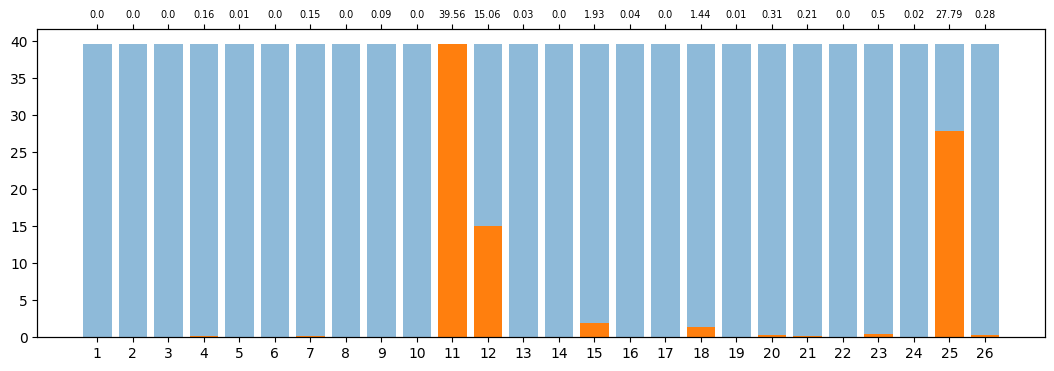

[0.0, 0.0, 0.0, 0.16, 0.01, 0.0, 0.15, 0.0, 0.09, 0.0, 39.56, 15.06, 0.03, 0.0, 1.93, 0.04, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 0.5, 0.02, 27.79, 0.28]


In [10]:

tot_perc_list = show_blast_distribution(ALL_DATASETS, return_perc = True)
print(tot_perc_list)

In [11]:
seed = 105619 # set the seed

# splits patients in categoties
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

# split patients indices in train, val and test
train_donors_idx, val_donors_idx, test_donors_idx = dataset_elaboration(multiple_donations, ALL_DATASETS, healthy_donors, blast_donors,
                        mixed_donors, seed = seed)

print(train_donors_idx, val_donors_idx, test_donors_idx)

# extract files from patients indices
train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
test_datasets_extracted = donation_extraction(test_donors_idx, multiple_donations, ALL_DATASETS)


{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
Precess starts. Dividing donors...
healthy_donors_idx, blast_donors_idx, mixed_donors_idx: [0, 2, 1], [0, 4, 2, 1, 3],[4, 0, 2, 1, 3]
Seting Train, Validation and Test idx...
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']
['12', '9', '13', '7'] ['6', '15', '3'] ['2', '8', '14', '11', '1', '4']


In [14]:
# classical CV 3 fold
def classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()

    tot_pat = []
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)

    from itertools import zip_longest
    
    tot_pat = []
    for pat_1, pat_2, pat_3 in zip_longest(h_pat, b_pat, m_pat, fillvalue=None):
        # Only add non-None values (or whatever fillvalue you choose)
        if pat_1 is not None:
            tot_pat.append(pat_1)
        if pat_2 is not None:
            tot_pat.append(pat_2)
        if pat_3 is not None:
            tot_pat.append(pat_3)
    
    print(h_pat, b_pat, m_pat)
    print(tot_pat)


    sub_len = int(len(tot_pat)/folds)
    print(sub_len)
    single_folds = []
    counter = 0
    for fold in range(folds - 1):
        print(fold)
        single_folds.append(tot_pat[counter: counter + sub_len])
        counter += sub_len
    single_folds.append(tot_pat[counter:])
    print(single_folds)

    tot_folds = []
    
    for n_fold in range(folds):
        val_fold = single_folds[n_fold - 1]
        train_fold = []
        for fold in single_folds:
            if fold != val_fold:
                train_fold += fold
        print(train_fold, val_fold)
        tot_folds.append([train_fold, val_fold])
    return tot_folds

chosen_perm = classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3)

['13', '15'] ['12', '6', '9'] ['3', '7']
['13', '12', '3', '15', '6', '7', '9']
2
0
1
[['13', '12'], ['3', '15'], ['6', '7', '9']]
['13', '12', '3', '15'] ['6', '7', '9']
['3', '15', '6', '7', '9'] ['13', '12']
['13', '12', '6', '7', '9'] ['3', '15']


In [15]:
print(multiple_donations) 

fold_features = {}
for i, (train_set, val_set) in enumerate(chosen_perm):
    #print(train_set, val_set)

    set_train_files, set_val_files = [], []
    for train_pat in train_set:
        train_files = multiple_donations[train_pat]
        set_train_files += train_files

    train_file_perc = list(np.array(tot_perc_list)[set_train_files])
    train_features = [train_set, train_file_perc, np.mean(train_file_perc), np.std(train_file_perc)]
    #print(train_features)
    
    for val_pat in val_set:
        val_files = multiple_donations[val_pat]
        set_val_files += val_files

    val_file_perc = list(np.array(tot_perc_list)[set_val_files])
    val_features = [val_set, val_file_perc, np.mean(val_file_perc), np.std(val_file_perc)]
    #print(val_features)
    
    fold_features[i] = [train_features, val_features]
    
    #print(set_train_files, set_val_files)
    print(train_file_perc, val_file_perc)


for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
        
        print(f'Train: {train_features}')
        print(f'Val: {val_features}\n')
    



{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}
[0.0, 0.15, 0.0, 0.03, 0.0, 0.0] [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28]
[0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.0, 0.15, 0.0]
[0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.03, 0.0, 0.0]
Train: [['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661]
Val: [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]

Train: [['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598]
Val: [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]

Train: [['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046]
Val: [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562

In [16]:
hyper = (nfilter, maxpool_p, learning_r)
print(hyper)

([3, 5, 7, 9], [0.01, 1.0, 5.0, 20.0, 100.0], [0.001])


In [17]:
%%time
fold_total_best= []
acc = []
f1 = []
hyper = (nfilter, maxpool_p, learning_r)
grid = False
labels = False
import time
for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        
        print(f'\nFold: {fold}\n')
        start = time.time()
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
            
        # import data (done every time to save memory)
        multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)
        train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
        val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
        test_datasets_extracted = donation_extraction(test_donors_idx, multiple_donations, ALL_DATASETS)
        del ALL_DATASETS
        
        """Artificial generation of Datasets used to train the model"""
        n_sub = 3
        seed = 105619
        n_cells = 100000  ################## 100000
        blast_perc = [0.001, 0.005, 0.01]
        
        new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, new_test_y = splitting_and_dataset_elaboration(train_datasets_extracted, 
                                                                                            val_datasets_extracted, test_datasets_extracted,
                                                                                            n_sub, n_cells, seed, blast_perc = blast_perc, per_perc = True)
    
    
    
        seed_list = [7359, 9654, 4557, 106, 2615, 6924, 5574, 4552, 2547, 3527, 18953, 23855, 81725, 6398, 3184, 6416, 78297, 96915, 17792, 96841]
    
        
        CellCnn = grid_or_rand_model(grid) #select the correct model
        
        train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)
        test = None
        trials = 3
        best_sub = 200  ############### # 200
        acc_ncells_5_to_plot = []
        f1_ncells_5_to_plot = []
        counter = 0
        max_acc = 0
        max_f1 = 0

        ncell_acc, ncell_f1 = [], []
        for n_cells in list(range(100, 800, 100)):  ############################## list(range(100, 800, 100))
            print(f'Number of cells: {n_cells}')
            ncell_start = time.time()
            seed = seed_list[counter + 3:]
            print(seed)
            
            print(f'model {i+ 1}. Number of cells: {n_cells}')
            models_lists = trials_train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                                          new_train_y, 
                                          val, #new_val_datasets_no_labels, 
                                          new_val_y, test, trials = trials,
                                          n_cell = n_cells, nsubset = best_nsub, max_epochs=20, #35, #################### 20
                                                    nrun=10, #5 ################### 10
                                                    seed_list = seed, hyper = hyper)
            
            predictions_list, results_list = trials_test_CellCNN_old(models_lists, val)
        
            pred_phenotype_df, accuracy_list, f1_scores_list = elaborate_predictions(predictions_list, new_val_y, results = True)
        
            mean_ncells_acc = np.mean(accuracy_list)
            acc_ncells_5_to_plot.append(mean_ncells_acc)
        
            mean_ncells_f1 = np.mean(f1_scores_list)
            f1_ncells_5_to_plot.append(mean_ncells_f1)

            ncell_acc.append(accuracy_list)
            ncell_f1.append(f1_scores_list)
            counter += 1

            ncell_end = time.time()
            print(f'Time Spent for the process the ncell value: {ncell_end - ncell_start}')
            print(f'Time Spent for the process the ncell value: {ncell_end - start}')
            
        best_3_values = find_best_nsubs(f1_ncells_5_to_plot, list(range(100, 800, 100)), n = 7)   ############### list(range(100, 800, 100)), n = 7
    
        acc.append(ncell_acc)
        f1.append(ncell_f1)
        
        fold_total_best.append(best_3_values)

        end = time.time()
        print(f'Time Spent for the process the Fold: {end - start}')


Fold: 0

Elaborating file 0: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\Enrico Didoli\0.Mas

C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

Trial 2 started
Seed used: 5230
Model defined...
Fitting started...
No labels detected. Labels set to False
[0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 0 0]
11
11

# ============================================= #
Run: 0

Seed: 5230

 filters: 3


 filters: 3

Epoch 1/20
71/71 [==============================] - 1s 8ms/step - loss: 0.6728 - f1_score: 0.4240 - val_loss: 0.7091 - val_f1_score: 0.3333
Epoch 2/20
71/71 [==============================] - 0s 4ms/step - loss: 0.6482 - f1_score: 0.4000 - val_loss: 0.7294 - val_f1_score: 0.3333
Epoch 3/20
71/71 [==============================] - 0s 4ms/step - loss: 0.6430 - f1_score: 0.4000 - val_loss: 0.7354 - val_f1_score: 0.3333
Epoch 4/20
71/71 [==============================] - 0s 4ms/step - loss: 0.6401 - f1_score: 0.4000 - val_loss: 0.7407 - val_f1_score: 0.3333
Epoch 5/20
71/71 [==============================] - 0s 4ms/step - loss: 0.6382 - f1_score: 0.4000 - val_loss: 0.7467 - val_f1_score: 0.3333
Epoch 6/20
439/439 [==============================

C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

Trial 3 started
Seed used: 20772
Model defined...
Fitting started...
No labels detected. Labels set to False
[0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 0 0]
11
11

# ============================================= #
Run: 0

Seed: 20772

 filters: 9


 filters: 9

Epoch 1/20
71/71 [==============================] - 1s 9ms/step - loss: 0.6574 - f1_score: 0.4039 - val_loss: 0.7369 - val_f1_score: 0.3333
Epoch 2/20
71/71 [==============================] - 0s 5ms/step - loss: 0.6315 - f1_score: 0.4136 - val_loss: 0.7437 - val_f1_score: 0.3333
Epoch 3/20
71/71 [==============================] - 0s 5ms/step - loss: 0.6130 - f1_score: 0.4851 - val_loss: 0.7498 - val_f1_score: 0.3333
Epoch 4/20
71/71 [==============================] - 0s 5ms/step - loss: 0.6012 - f1_score: 0.5402 - val_loss: 0.7486 - val_f1_score: 0.3333
Epoch 5/20
71/71 [==============================] - 0s 5ms/step - loss: 0.5869 - f1_score: 0.5772 - val_loss: 0.7403 - val_f1_score: 0.3335
Epoch 6/20
439/439 [============================

...

1/1 [==============================] - 0s 83ms/step

 filters: 9

1/1 [==============================] - 0s 109ms/step

 filters: 9

1/1 [==============================] - 0s 106ms/step
Done
Trial 1 Done!

3
Prediction started...

 filters: 9



C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

1/1 [==============================] - 0s 118ms/step

 filters: 9

1/1 [==============================] - 0s 117ms/step

 filters: 9

1/1 [==============================] - 0s 117ms/step
Done
Trial 2 Done!

3
Prediction started...

 filters: 7



C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Anaconda37\envs\jupyter_env\lib\site-packages\sklearn\utils\validat

1/1 [==============================] - 0s 105ms/step

 filters: 5

1/1 [==============================] - 0s 108ms/step

 filters: 9

1/1 [==============================] - 0s 123ms/step
Done
Trial 3 Done!

Trial 0 Accuracy: 0.6666666666666666
Trial 0 F1_score: 0.6666666666666666
Trial 1 Accuracy: 1.0
Trial 1 F1_score: 1.0
Trial 2 Accuracy: 0.8888888888888888
Trial 2 F1_score: 0.8
             0  1  2  3  4  5  6  7  8
0            1  1  1  1  1  1  0  0  0
1            1  1  1  0  0  0  0  0  0
2            0  1  1  0  0  0  0  0  0
True Labels  1  1  1  0  0  0  0  0  0
mean_accuracy over the ten trials: 0.8518518518518517
accuracy_std over the ten trials: 0.1385799032138497
mean_f1 over the ten trials: 0.8222222222222223
std_f1 over the ten trials: 0.13698697784375505
Time Spent for the process the ncell value: 2054.1519963741302
Time Spent for the process the ncell value: 9293.62524843216
5 best f1_score values: [1.0, 1.0, 0.9523809523809524, 0.8666666666666667, 0.8412698412698413,

In [18]:
#best_3_values = find_best_nsubs(f1_ncells_5_to_plot, list(range(100, 200, 100)), n = 1)
#print(best_3_values)
#fold_total_best.append(list(best_3_values))
print(fold_total_best)
print(acc)
print(f1)

[array([100, 200, 300, 400, 500, 600, 700]), array([100, 200, 300, 400, 500, 600, 700]), array([100, 200, 300, 400, 500, 600, 700])]
[[[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5555555555555556, 0.5555555555555556, 0.6111111111111112], [0.5555555555555556, 0.5, 0.5], [0.5, 0.5, 0.5555555555555556], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]], [[1.0, 1.0, 1.0], [0.7777777777777778, 1.0, 1.0], [0.7777777777777778, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 0.7777777777777778], [1.0, 1.0, 0.7777777777777778]], [[0.8888888888888888, 0.8888888888888888, 1.0], [1.0, 0.8888888888888888, 1.0], [0.8888888888888888, 0.6666666666666666, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.6666666666666666, 0.6666666666666666], [0.6666666666666666, 1.0, 0.8888888888888888]]]
[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.2, 0.2, 0.36363636363636365], [0.2, 0.0, 0.0], [0.0, 0.0, 0.2], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], [[1.0, 1.0, 1.0], [0.75, 1.0, 1.0], [0.75, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1

In [19]:
folds_to_save = []
for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        folds_to_save.append([train_features, val_features])
print(folds_to_save)

[[[['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661], [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]], [[['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598], [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]], [[['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046], [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562373095]]]


In [20]:
mod = 3
tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\folder_testing\\model_{mod}\\'
os.makedirs(tuning_ncell_test_path, exist_ok=True)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(acc, f, default = default_serializer, ensure_ascii = False, indent = 2)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(f1, f, default = default_serializer, ensure_ascii = False, indent = 2)
with open(f'{tuning_ncell_test_path}tested_folds_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(folds_to_save, f, default = default_serializer, ensure_ascii = False, indent = 2)
with open(f'{tuning_ncell_test_path}blast_perc_{mod}.json', 'w', encoding = "utf-8") as f:
    json.dump(blast_perc, f, default = default_serializer, ensure_ascii = False, indent = 2)


[[['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661], [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]]
[0.5, 0.5, 0.5222222222222223, 0.5111111111111111, 0.5111111111111111, 0.5, 0.5]
[0.0, 0.0, 0.10526315789473684, 0.041666666666666664, 0.041666666666666664, 0.0, 0.0]


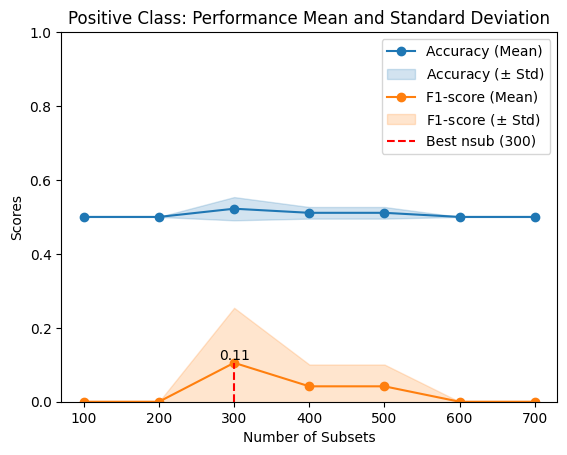

[[['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598], [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]]
[0.9555555555555556, 0.8666666666666667, 0.8888888888888888, 0.9777777777777779, 0.9777777777777779, 0.9777777777777779, 1.0]
[0.9259259259259259, 0.7367724867724869, 0.8888888888888888, 0.9696969696969697, 0.9696969696969697, 0.9696969696969697, 1.0]


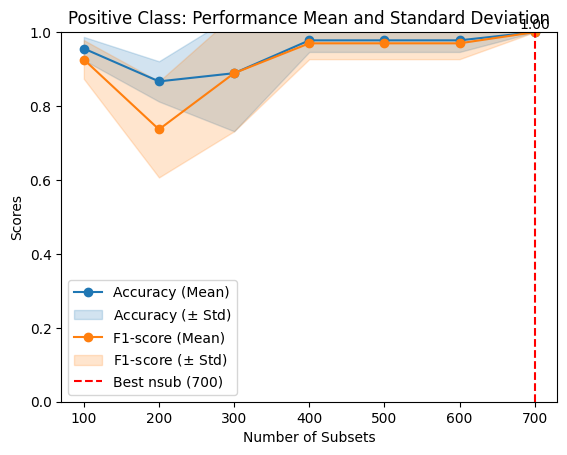

[[['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046], [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562373095]]
[0.7111111111111111, 0.9333333333333332, 0.8666666666666667, 0.9111111111111111, 0.888888888888889, 0.9555555555555556, 0.8444444444444444]
[0.19047619047619047, 0.8571428571428571, 0.7367724867724869, 0.8333333333333334, 0.7962962962962963, 0.9259259259259259, 0.6349206349206349]


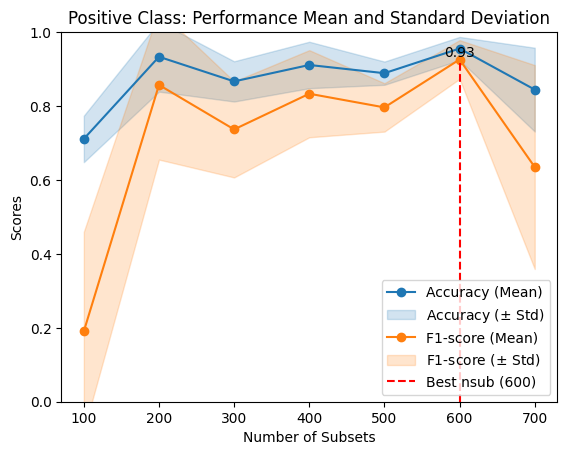

In [6]:
def plot_nsub_step_2(acc_5_means, f1_5_means, n_sub_step2_x_axis):
    
    
    acc_ncells_5_means = [np.mean(acc) for acc in acc_5_means]
    print(acc_ncells_5_means)
    f1_ncells_5_means = [np.mean(f1) for f1 in f1_5_means]
    print(f1_ncells_5_means)
    
    acc_ncells_5_stds = [np.std(acc) for acc in acc_5_means]

    f1_ncells_5_stds = [np.std(f1) for f1 in f1_5_means]
    
    max_idx = f1_ncells_5_means.index(np.max(f1_ncells_5_means))
    # Plot Accuracy Mean
    plt.plot(n_sub_step2_x_axis, acc_ncells_5_means, marker='o', label='Accuracy (Mean)', color='C0')
    # Plot Accuracy Std as a shaded region
    acc_upper = np.array(acc_ncells_5_means) + np.array(acc_ncells_5_stds)
    acc_lower = np.array(acc_ncells_5_means) - np.array(acc_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, acc_lower, acc_upper, color='C0', alpha=0.2, label='Accuracy ($\pm$ Std)')
    
    # Plot F1-score Mean
    plt.plot(n_sub_step2_x_axis, f1_ncells_5_means, marker='o', label='F1-score (Mean)', color='C1')
    # Plot F1-score Std as a shaded region
    f1_upper = np.array(f1_ncells_5_means) + np.array(f1_ncells_5_stds)
    f1_lower = np.array(f1_ncells_5_means) - np.array(f1_ncells_5_stds)
    plt.fill_between(n_sub_step2_x_axis, f1_lower, f1_upper, color='C1', alpha=0.2, label='F1-score ($\pm$ Std)')

    y = f1_ncells_5_means[max_idx]
    plt.text(n_sub_step2_x_axis[max_idx], y, f"{y:.2f}", ha='center', va='bottom')
    
    plt.vlines(x = n_sub_step2_x_axis[max_idx], ymin = 0, ymax = np.max(f1_ncells_5_means), color='red', linestyle='--', label=f'Best nsub ({n_sub_step2_x_axis[max_idx]})')
    plt.ylim(0,1)
    plt.title('Positive Class: Performance Mean and Standard Deviation')
    plt.xlabel("Number of Subsets")
    plt.ylabel("Scores")
    plt.legend()
    plt.show()
mod = 4
tuning_ncell_test_path = f'{fixed_path}CellCNN\\results\\old\\ncells_tuning\\folder_testing\\model_{mod}\\'
with open(f'{tuning_ncell_test_path}tuning_ncell_test_acc_{mod}.json', 'r', encoding = "utf-8") as f:
    acc_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tuning_ncell_test_f1_{mod}.json', 'r', encoding = "utf-8") as f:
    f1_imported = json.load(f)
with open(f'{tuning_ncell_test_path}tested_folds_{mod}.json', 'r', encoding = "utf-8") as f:
    tested_folds = json.load(f)
    
for acc_fold_im, f1_fold_im, fold in zip(acc_imported, f1_imported, tested_folds):
    print(fold)
    n_cells_list = list(range(100, 800, 100))
    plot_nsub_step_2(acc_fold_im, f1_fold_im, n_cells_list)


In [7]:
with open(f'{tuning_ncell_test_path}blast_perc_{mod}.json', 'r', encoding = "utf-8") as f:
    blast_perc = json.load(f)
print(blast_perc)

[0.0001, 0.0005, 0.001, 0.005, 0.01]


In [25]:
for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
        
        print(f'Train: {train_features}')
        print(f'Val: {val_features}\n')
    

Train: [['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661]
Val: [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]

Train: [['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598]
Val: [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]

Train: [['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046]
Val: [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562373095]



[['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661] [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]
[['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598] [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]
[['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046] [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562373095]


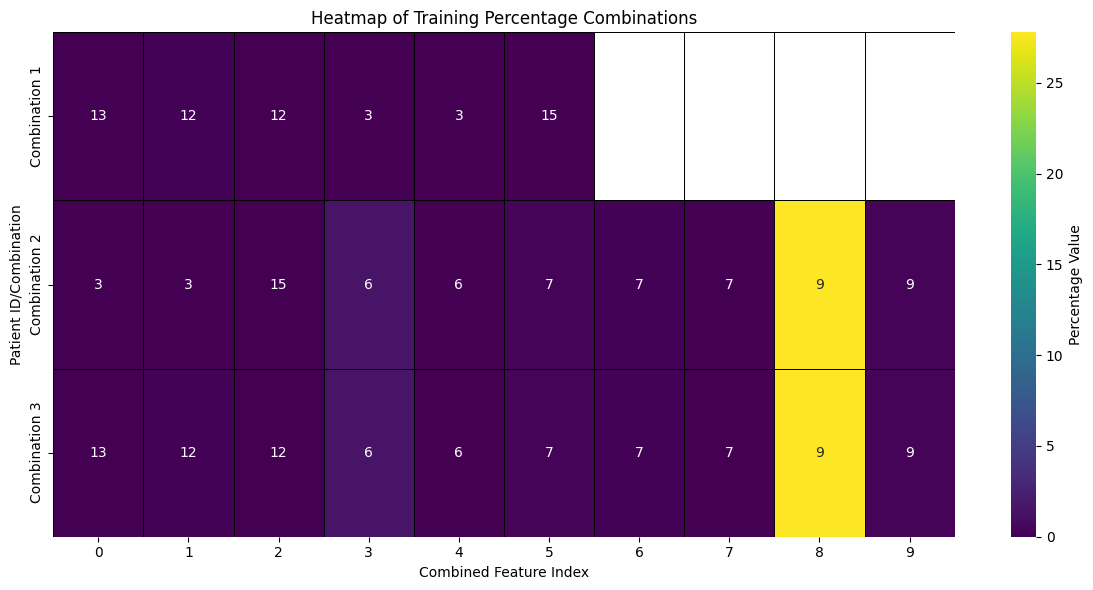

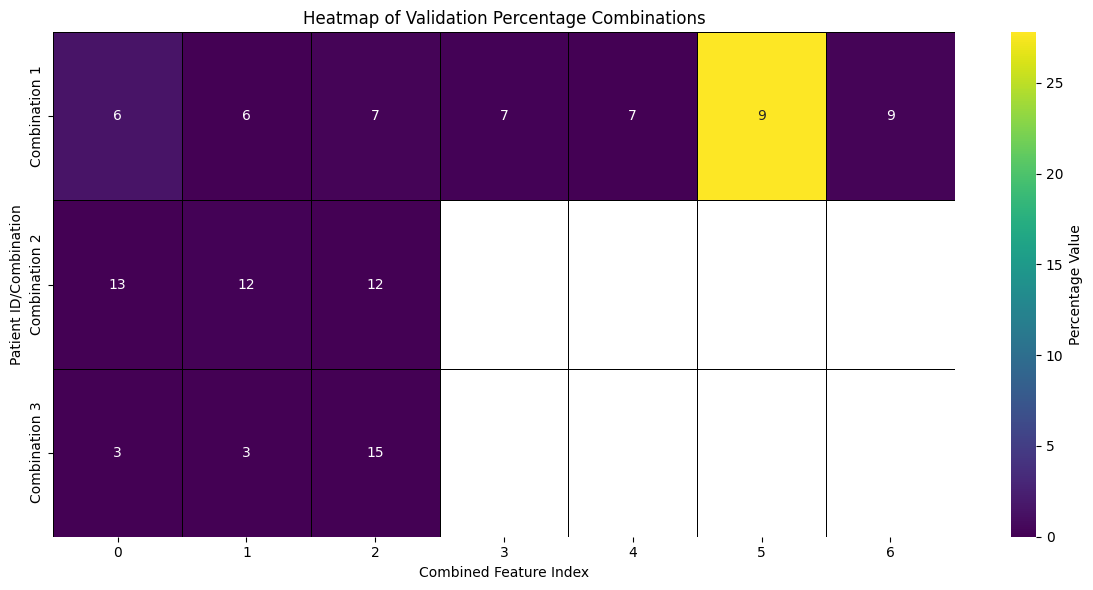

In [26]:
import seaborn as sns
train_heat, val_heat = [], []
train_labels, val_labels = [], []
for fold, (train_f, val_f) in fold_features.items():
    print(train_f, val_f)
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])

def heatmap_fold(train_heat, train_labels, multiple_donations, fold = 'train'):
    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
        
    patient_labels = []
    for fold in train_labels:
        labels = []
        
        for idx in fold:
             labels += [int(idx)]*len(multiple_donations[idx])
    
        patient_labels.append(labels)
    
    
    # Convert the list of lists into a DataFrame
    train_heat_df = pd.DataFrame(train_heat)
    train_labels_df = pd.DataFrame(patient_labels)
    
    train_heat_df.index = [f'Combination {i+1}' for i in range(len(train_heat_df))]
    train_labels_df.index = [f'Combination {i+1}' for i in range(len(train_labels_df))]

    
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(
        train_heat_df,
        annot=train_labels_df, # Annotation is now set to True
        #annot = True,
        #mt=".2f",  # Format the percentage values to 2 decimal places
        cmap='viridis',
        cbar_kws={'label': 'Percentage Value'},
        linewidths=.5,
        linecolor='black'
    )

    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
    plt.title(f'Heatmap of {fold_text} Percentage Combinations')
    plt.ylabel('Patient ID/Combination')
    plt.xlabel('Combined Feature Index')
    
    # Add custom text labels for the sections
    #plt.text(split_point / 2, -0.5, f'{fold_text} Set Features', 
    #         ha='center', va='center', fontsize=12, color='darkred', weight='bold', transform=ax.transData)
    
    plt.tight_layout()
    plt.savefig(f'heatmap_{fold_text}_validation.png')
    
    #print(f"The split point (index where the line is drawn) is: {split_point}")

heatmap_fold(train_heat, train_labels, multiple_donations)
heatmap_fold(val_heat, val_labels, multiple_donations, 'valid')